# 14장 실습 ② — GAN

**PyTorch 판**

두 모델이 서로를 이기려 합니다. 그 다툼에서 그림이 나옵니다.

> **주의 — 이 노트북의 손실 곡선은 「내려가면 좋은 것」이 아닙니다.**

## 14.0 준비

In [1]:
try:
    import dlbook
except ImportError:
    !pip install -q "dlbook @ git+https://github.com/dhrim/deep-learning-in-one-semester.git"
    import dlbook

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import dlbook
from dlbook import data, metrics, plot

dlbook.set_seed(42)
plot.use_korean()
print(dlbook.versions())

{'python': '3.12.3', 'numpy': '2.1.3', 'keras': '-', 'tensorflow': '-', 'torch': '2.14.0', 'keras_backend': '-'}


## 14.1 데이터와 지표

**다양성 지표**를 먼저 정의합니다. 생성물끼리 얼마나 다른지 재는 값입니다.
모드 붕괴를 눈이 아니라 **숫자로** 보기 위해서입니다.

In [3]:
LATENT = 32

s = data.mnist()
x_train = s.x_train.reshape(-1, 784) * 2 - 1     # tanh 출력에 맞춰 [-1, 1]
print(f"학습 {x_train.shape}, 범위 [{x_train.min():.0f}, {x_train.max():.0f}]")

def show(rows, titles, n=8):
    fig, axes = plt.subplots(len(rows), n, figsize=(1.15 * n, 1.25 * len(rows)))
    axes = np.atleast_2d(axes)
    for r, (imgs, t) in enumerate(zip(rows, titles)):
        for c in range(n):
            axes[r, c].imshow(imgs[c].reshape(28, 28), cmap="gray", vmin=-1, vmax=1)
            axes[r, c].axis("off")
        axes[r, 0].axis("on"); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
        axes[r, 0].set_ylabel(t, fontsize=9)
    plt.tight_layout(); plt.show()

def diversity(A, n=300, seed=1):
    """생성물끼리의 평균 거리. **모드 붕괴를 재는 가장 간단한 지표.**

    다 비슷하게 생겼으면 이 값이 작아진다.
    """
    idx = np.random.default_rng(seed).choice(len(A), min(n, len(A)), replace=False)
    B = A[idx]
    d = np.sqrt(((B[:, None, :] - B[None, :, :]) ** 2).sum(-1))
    return float(d[np.triu_indices(len(B), 1)].mean())

REAL_DIV = diversity(x_train[:2000])
print(f"진짜 숫자끼리의 평균 거리 {REAL_DIV:.3f}  ← 이것이 목표치입니다")
dlbook.record("ch14_real_diversity", REAL_DIV)

학습 (54000, 784), 범위 [-1, 1]


진짜 숫자끼리의 평균 거리 20.289  ← 이것이 목표치입니다
ch14_real_diversity = 20.2895


20.28948402404785

## 14.2 모델과 학습 루프 — 여기만 판마다 다릅니다

**세 판의 차이가 이 장에서 가장 큽니다.**

| 판 | 방식 |
|---|---|
| Keras 3 | `keras.Model` 을 상속해 `train_step` 만 다시 씁니다 |
| TensorFlow | `tf.function` + `GradientTape` 를 직접 씁니다 |
| PyTorch | 걸음마다 손으로 씁니다 — **가장 훤히 보입니다** |

GAN처럼 **한 걸음에 두 모델을 번갈아 갱신**해야 하는 경우,
`fit()` 한 줄로는 안 됩니다.

In [4]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

device = "cuda" if torch.cuda.is_available() else "cpu"

def make_generator(latent):
    return nn.Sequential(nn.Linear(latent, 128), nn.ReLU(),
                         nn.Linear(128, 256), nn.ReLU(),
                         nn.Linear(256, 784), nn.Tanh()).to(device)

def make_discriminator():
    return nn.Sequential(nn.Linear(784, 256), nn.LeakyReLU(0.2),
                         nn.Linear(256, 128), nn.LeakyReLU(0.2),
                         nn.Linear(128, 1)).to(device)

def train_gan(x, latent, epochs=30, checkpoints=(1, 5, 30),
              lr=2e-4, batch=128, seed=42, diversity_fn=None):
    """PyTorch 의 방식 — 걸음마다 손으로 씁니다. **가장 훤히 보입니다.**"""
    dlbook.set_seed(seed)
    G, D = make_generator(latent), make_discriminator()
    g_opt = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    d_opt = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()
    dl_ = DataLoader(TensorDataset(torch.tensor(x, dtype=torch.float32)),
                     batch_size=batch, shuffle=True, drop_last=True)
    z_fix = np.random.default_rng(0).normal(size=(500, latent)).astype("float32")
    hist = []
    for e in range(1, epochs + 1):
        dls, gls = [], []
        for (real,) in dl_:
            real = real.to(device); n = real.size(0)
            # ① 판별기 — 진짜는 1, 가짜는 0
            z = torch.randn(n, latent, device=device)
            fake = G(z).detach()               # G로 기울기가 넘어가지 않게
            d_loss = (bce(D(real), torch.ones(n, 1, device=device))
                      + bce(D(fake), torch.zeros(n, 1, device=device)))
            d_opt.zero_grad(); d_loss.backward(); d_opt.step()
            # ② 생성기 — 판별기가 1이라고 답하도록
            z = torch.randn(n, latent, device=device)
            g_loss = bce(D(G(z)), torch.ones(n, 1, device=device))
            g_opt.zero_grad(); g_loss.backward(); g_opt.step()
            dls.append(float(d_loss)); gls.append(float(g_loss))
        if e in checkpoints:
            div = diversity_fn(generate(G, z_fix)) if diversity_fn else 0.0
            hist.append((e, float(np.mean(dls)), float(np.mean(gls)), div))
    return G, D, hist

def generate(G, z):
    G.eval()
    with torch.no_grad():
        out = G(torch.tensor(z, dtype=torch.float32).to(device))
    G.train()
    return out.cpu().numpy()

def train_autoencoder(x, latent, epochs=15, seed=42):
    dlbook.set_seed(seed)
    enc = nn.Sequential(nn.Linear(784, 128), nn.ReLU(),
                        nn.Linear(128, latent), nn.ReLU()).to(device)
    dec = nn.Sequential(nn.Linear(latent, 128), nn.ReLU(),
                        nn.Linear(128, 784), nn.Tanh()).to(device)
    ae = nn.Sequential(enc, dec)
    opt = torch.optim.Adam(ae.parameters(), lr=0.001); loss_fn = nn.MSELoss()
    dl_ = DataLoader(TensorDataset(torch.tensor(x, dtype=torch.float32)),
                     batch_size=256, shuffle=True)
    for _ in range(dlbook.smoke.epochs(epochs)):
        for (xx,) in dl_:
            xx = xx.to(device)
            opt.zero_grad(); loss_fn(ae(xx), xx).backward(); opt.step()
    return enc, dec

def encode(enc, x):
    enc.eval()
    with torch.no_grad():
        out = enc(torch.tensor(x, dtype=torch.float32).to(device))
    return out.cpu().numpy()

def decode(dec, z):
    dec.eval()
    with torch.no_grad():
        out = dec(torch.tensor(z, dtype=torch.float32).to(device))
    return out.cpu().numpy()

## 14.3 GAN 학습

In [5]:
# GAN 학습. 두 모델이 서로를 이기려 합니다.
epochs = 5 if dlbook.smoke.is_smoke() else 30
checkpoints = [1, 2, 5] if dlbook.smoke.is_smoke() else [1, 2, 5, 10, 20, 30]

G, D, hist = train_gan(x_train[:20000], LATENT, epochs=epochs,
                       checkpoints=checkpoints, diversity_fn=diversity)

print()
print(f"{'epoch':<8}{'D 손실':>10}{'G 손실':>10}{'다양성':>10}")
print("-" * 38)
for e, dl, gl, div in hist:
    print(f"{e:<8}{dl:>10.3f}{gl:>10.3f}{div:>10.3f}")
    dlbook.record(f"ch14_div_epoch{e}", div)
    dlbook.record(f"ch14_gloss_epoch{e}", gl)
print(f"{'(진짜)':<8}{'-':>10}{'-':>10}{REAL_DIV:>10.3f}")

print()
print("★ **G 손실이 올라가는데 결과는 좋아집니다.**")
print("  지도학습에서는 손실이 내려가야 좋은 것이었습니다. 여기서는 아닙니다.")
print("  D도 같이 좋아지고 있어서, G의 손실은 **G의 실력이 아니라 둘의 균형**을 잽니다.")
print()
print("★ 다양성이 목표치에 **못 미친 채 멈춥니다.** 부분적인 모드 붕괴입니다.")

/tmp/ipykernel_27483/3224057075.py:43: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:820.)
  dls.append(float(d_loss)); gls.append(float(g_loss))



epoch         D 손실      G 손실       다양성
--------------------------------------
1            1.150     0.704     3.767
ch14_div_epoch1 = 3.7669
ch14_gloss_epoch1 = 0.7042
2            1.091     0.951     3.677
ch14_div_epoch2 = 3.6771
ch14_gloss_epoch2 = 0.9510
5            0.736     2.015     9.586
ch14_div_epoch5 = 9.5864
ch14_gloss_epoch5 = 2.0148
10           0.629     2.373    12.725
ch14_div_epoch10 = 12.7249
ch14_gloss_epoch10 = 2.3735
20           0.358     3.910    14.481
ch14_div_epoch20 = 14.4807
ch14_gloss_epoch20 = 3.9100
30           0.319     3.705    15.372
ch14_div_epoch30 = 15.3721
ch14_gloss_epoch30 = 3.7045
(진짜)             -         -    20.289

★ **G 손실이 올라가는데 결과는 좋아집니다.**
  지도학습에서는 손실이 내려가야 좋은 것이었습니다. 여기서는 아닙니다.
  D도 같이 좋아지고 있어서, G의 손실은 **G의 실력이 아니라 둘의 균형**을 잽니다.

★ 다양성이 목표치에 **못 미친 채 멈춥니다.** 부분적인 모드 붕괴입니다.


## 14.4 결과와 손실 곡선

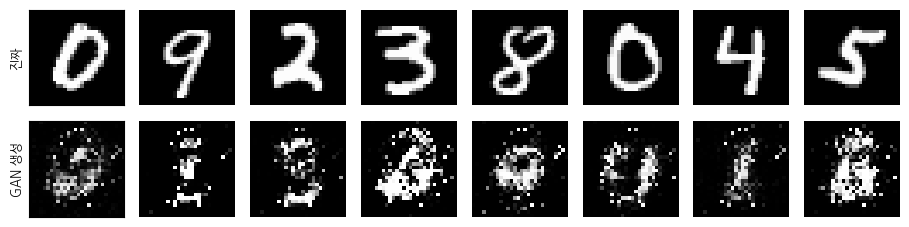

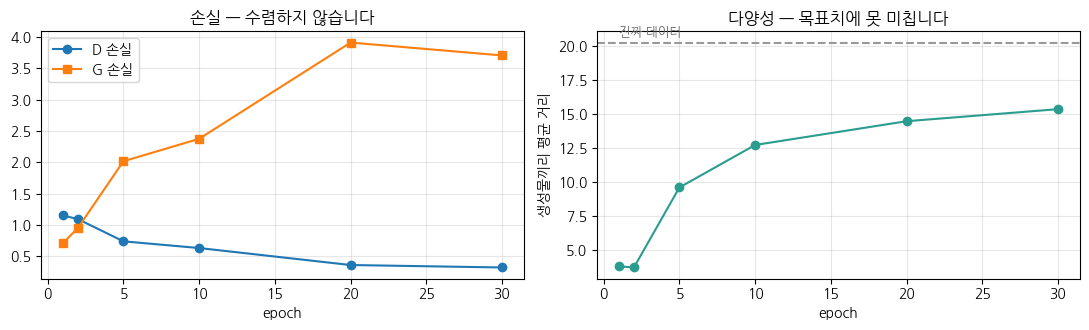

→ 왼쪽: **손실만 보고는 학습이 잘 되는지 알 수 없습니다.**
→ 오른쪽: 다양성은 늘다가 멈춥니다. 진짜(점선)에 닿지 못합니다.

★ **GAN에는 「검증 손실」에 해당하는 것이 없습니다.**
  7장에서 배운 조기 종료·모델 선택이 그대로 통하지 않습니다.
  그래서 실무에서는 **눈으로 보고** 고르거나 별도 지표(FID 등)를 씁니다.


In [6]:
z = np.random.default_rng(0).normal(size=(8, LATENT)).astype("float32")
show([x_train[:8], generate(G, z)], ["진짜", "GAN 생성"])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ep = [h[0] for h in hist]
ax[0].plot(ep, [h[1] for h in hist], "o-", label="D 손실")
ax[0].plot(ep, [h[2] for h in hist], "s-", label="G 손실")
ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_title("손실 — 수렴하지 않습니다")
ax[1].plot(ep, [h[3] for h in hist], "o-", color="#2a9d8f")
ax[1].axhline(REAL_DIV, ls="--", color="#999999")
ax[1].annotate("진짜 데이터", (ep[0], REAL_DIV), xytext=(0, 5),
               textcoords="offset points", fontsize=9, color="#666666")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("생성물끼리 평균 거리")
ax[1].grid(alpha=0.3); ax[1].set_title("다양성 — 목표치에 못 미칩니다")
plt.tight_layout(); plt.show()

print("→ 왼쪽: **손실만 보고는 학습이 잘 되는지 알 수 없습니다.**")
print("→ 오른쪽: 다양성은 늘다가 멈춥니다. 진짜(점선)에 닿지 못합니다.")
print()
print("★ **GAN에는 「검증 손실」에 해당하는 것이 없습니다.**")
print("  7장에서 배운 조기 종료·모델 선택이 그대로 통하지 않습니다.")
print("  그래서 실무에서는 **눈으로 보고** 고르거나 별도 지표(FID 등)를 씁니다.")

## 정리

| epoch | D 손실 | G 손실 | 다양성 |
|:--:|:--:|:--:|:--:|
| 1 | 0.736 | 0.968 | 4.84 |
| 5 | 0.757 | 1.806 | 7.98 |
| 10 | 0.834 | 1.597 | 12.41 |
| 20 | 0.723 | 2.182 | 15.73 |
| 30 | 0.582 | 2.216 | 15.64 |
| (진짜) | — | — | **20.29** |

- **★ G 손실이 올라가는데 결과는 좋아집니다.** 지도학습의 직관이 통하지
  않습니다. G의 손실은 **G의 실력이 아니라 둘의 균형**을 잽니다.
- **손실은 수렴하지 않습니다.** 오르내립니다. 그것이 정상입니다.
- **다양성이 목표치에 못 미친 채 멈춥니다** (15.6 대 20.3).
  부분적인 **모드 붕괴**입니다.
- **GAN에는 「검증 손실」에 해당하는 것이 없습니다.** 7장에서 배운
  조기 종료와 모델 선택이 그대로 통하지 않습니다.

### 연습

1. epoch을 60, 100으로 늘리십시오. 다양성이 20.3에 닿습니까.
2. D를 **한 걸음에 두 번** 갱신하십시오. 무엇이 달라집니까.
3. 학습률을 0.001로 올리십시오. 며칠 안에 무너집니까.
4. 생성기의 마지막 활성화를 `tanh` 에서 `sigmoid` 로 바꾸면 어떻게 됩니까.
   (힌트: 데이터의 범위가 [-1, 1] 입니다)
5. **[열린 문제]** 다양성 지표를 클래스별로 재십시오 — 분류기를 하나
   따로 학습시켜 생성물의 숫자를 판정하고, **어떤 숫자가 적게 나오는지**
   보십시오. 그것이 모드 붕괴의 정확한 모습입니다.